<a href="https://colab.research.google.com/github/BhagyashreeMohalkar/SmartWasteAI/blob/main/SmartWasteAI_01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartWasteAI — Waste Dataset EDA

## 1. Project Overview

## 2. Import Libraries

## 3. Dataset Setup

## 4. Dataset Structure

## 5. Class Distribution

## 6. Image Analysis

## 7. Sample Images

## 8. Data Quality Checks

## 9. Findings

## 10. Next Steps

In [ ]:
!pip install -q kaggle

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("Environment ready!")

Environment ready!


In [ ]:
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Enter your Kaggle API token: ")

Enter your Kaggle API token: ··········


In [ ]:
!kaggle datasets list --max-size 5

ref                                                               title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
georgymamarin/kaggriculture-episodes                              Kaggriculture Episodes                                        0  2026-09-04 04:50:16.840000          16499         59                1  
omkadam05/semicon-v2-dual-dataset                                 MicroRestore: Microscopy Image Restoration Dataset   7407237601  2026-08-28 15:16:16.333000             22          8                1  
anhadmahajan06/ps-s6e8predicting-smartphone-addiction-submission  PS S6E8|Predicting Smartphone Addiction Submission     64532018  2026-08-10 14:11:40.307000            253          1     

In [ ]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.2 MB/s eta 0:00:00


In [ ]:
!kaggle --version

Kaggle CLI 2.2.4


In [2]:
!mkdir -p /content/data

!kaggle datasets download -d huberthamelin/garbage-classification-labels-corrections \
    -p /content/data \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/huberthamelin/garbage-classification-labels-corrections
License(s): DbCL-1.0
100% 497M/497M [00:26<00:00, 19.4MB/s]



In [3]:
import os

print("Contents of /content/data:")
print(os.listdir("/content/data"))

Contents of /content/data:
['labels_corrections.csv', 'garbage_classification_corrected', 'garbage_classification_enhanced']


In [4]:
import os

base_path = "/content/data"

for folder in ["garbage_classification_corrected", "garbage_classification_enhanced"]:
    path = os.path.join(base_path, folder)

    print(f"\n📁 {folder}")
    print("-" * 50)

    if os.path.exists(path):
        classes = sorted(os.listdir(path))
        print("Number of classes:", len(classes))
        print("Classes:")
        for cls in classes:
            print("  -", cls)
    else:
        print("Folder not found!")


📁 garbage_classification_corrected
--------------------------------------------------
Number of classes: 12
Classes:
  - battery
  - biological
  - brown-glass
  - cardboard
  - clothes
  - green-glass
  - metal
  - paper
  - plastic
  - shoes
  - trash
  - white-glass

📁 garbage_classification_enhanced
--------------------------------------------------
Number of classes: 12
Classes:
  - battery
  - biological
  - brown-glass
  - cardboard
  - clothes
  - green-glass
  - metal
  - paper
  - plastic
  - shoes
  - trash
  - white-glass


In [5]:
import os
import pandas as pd

base_path = "/content/data"

results = []

for folder in ["garbage_classification_corrected", "garbage_classification_enhanced"]:
    path = os.path.join(base_path, folder)

    for class_name in sorted(os.listdir(path)):
        class_path = os.path.join(path, class_name)

        if os.path.isdir(class_path):
            image_count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
            ])

            results.append({
                "Dataset": folder,
                "Class": class_name,
                "Images": image_count
            })

df_counts = pd.DataFrame(results)

display(df_counts)

,Dataset,Class,Images
0,garbage_classification_corrected,battery,944
1,garbage_classification_corrected,biological,983
2,garbage_classification_corrected,brown-glass,603
3,garbage_classification_corrected,cardboard,896
4,garbage_classification_corrected,clothes,5286
5,garbage_classification_corrected,green-glass,613
6,garbage_classification_corrected,metal,767
7,garbage_classification_corrected,paper,1043
8,garbage_classification_corrected,plastic,864
9,garbage_classification_corrected,shoes,2007


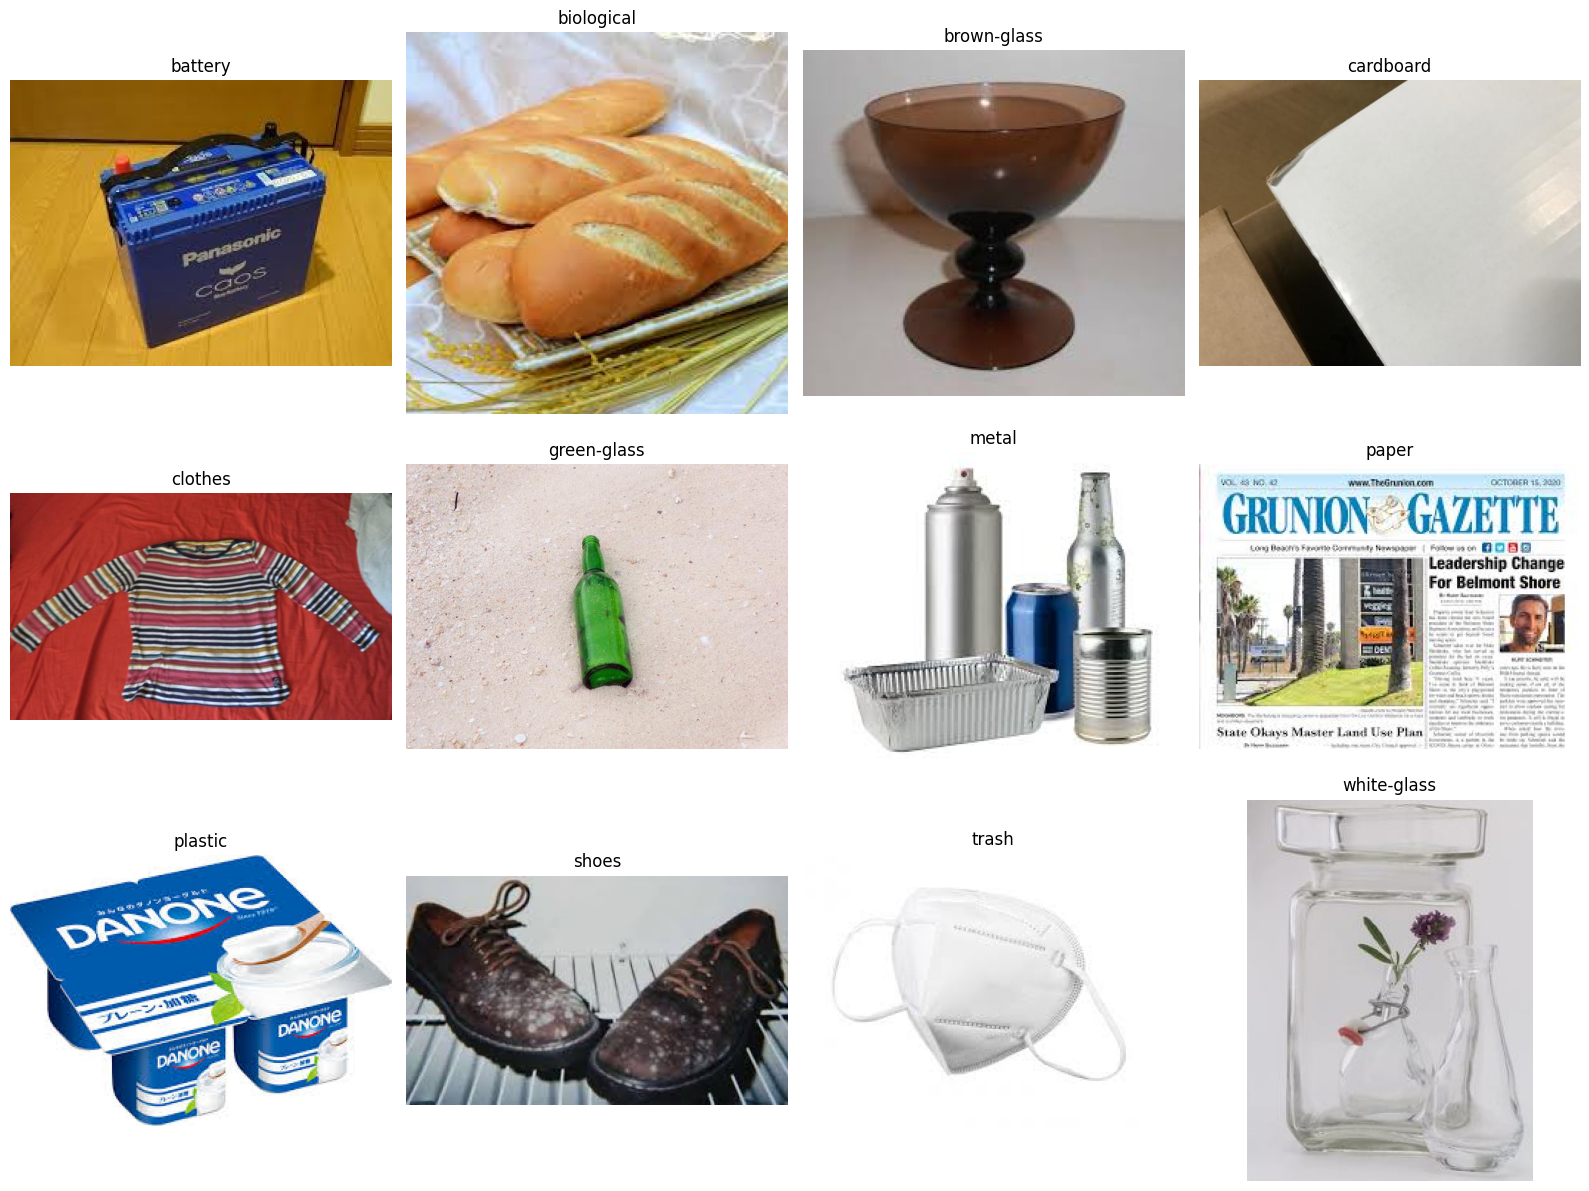

In [6]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/content/data/garbage_classification_enhanced"

classes = sorted([
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
])

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    image_file = random.choice(images)
    image_path = os.path.join(class_path, image_file)

    image = Image.open(image_path)

    axes[i].imshow(image)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [7]:
from PIL import Image
import os
from collections import Counter

dataset_path = "/content/data/garbage_classification_enhanced"

dimension_counts = Counter()
corrupted_images = []
total_images = 0

for class_name in sorted(os.listdir(dataset_path)):

    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    for filename in os.listdir(class_path):

        if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            continue

        image_path = os.path.join(class_path, filename)
        total_images += 1

        try:
            with Image.open(image_path) as img:
                dimension_counts[img.size] += 1
                img.verify()

        except Exception:
            corrupted_images.append(image_path)

print("Total images:", total_images)
print("Corrupted images:", len(corrupted_images))

print("\nMost common image dimensions:")
for dimension, count in dimension_counts.most_common(10):
    print(f"{dimension}: {count} images")

Total images: 15870
Corrupted images: 0

Most common image dimensions:
(400, 533): 2592 images
(512, 384): 2356 images
(225, 225): 1992 images
(400, 534): 1078 images
(275, 183): 685 images
(259, 194): 543 images
(533, 400): 387 images
(400, 711): 300 images
(194, 259): 230 images
(534, 400): 163 images


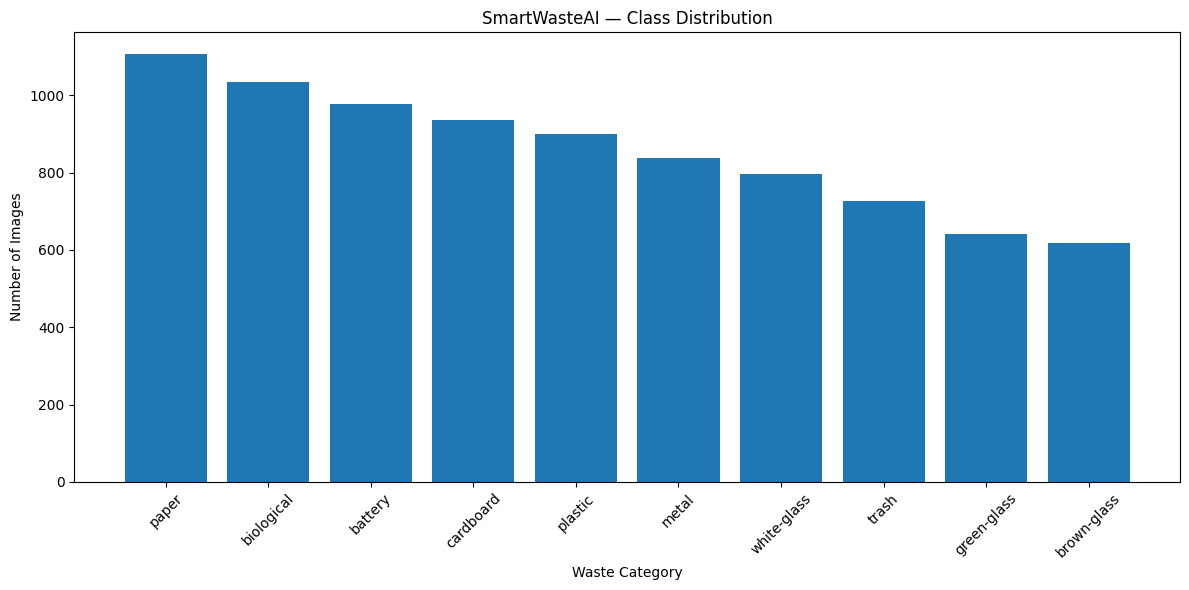

In [8]:
import matplotlib.pyplot as plt

selected_classes = [
    "battery",
    "biological",
    "brown-glass",
    "cardboard",
    "green-glass",
    "metal",
    "paper",
    "plastic",
    "trash",
    "white-glass"
]

selected_counts = df_counts[
    (df_counts["Dataset"] == "garbage_classification_enhanced") &
    (df_counts["Class"].isin(selected_classes))
].copy()

selected_counts = selected_counts.sort_values("Images", ascending=False)

plt.figure(figsize=(12, 6))

plt.bar(
    selected_counts["Class"],
    selected_counts["Images"]
)

plt.title("SmartWasteAI — Class Distribution")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
print("Selected classes:", len(selected_counts))
print("Total selected images:", selected_counts["Images"].sum())

display(selected_counts)

Selected classes: 10
Total selected images: 8578


,Dataset,Class,Images
19,garbage_classification_enhanced,paper,1108
13,garbage_classification_enhanced,biological,1035
12,garbage_classification_enhanced,battery,979
15,garbage_classification_enhanced,cardboard,936
20,garbage_classification_enhanced,plastic,901
18,garbage_classification_enhanced,metal,837
23,garbage_classification_enhanced,white-glass,796
22,garbage_classification_enhanced,trash,726
17,garbage_classification_enhanced,green-glass,641
14,garbage_classification_enhanced,brown-glass,619


In [10]:
import os
import hashlib
from collections import defaultdict

dataset_path = "/content/data/garbage_classification_enhanced"

selected_classes = [
    "battery",
    "biological",
    "brown-glass",
    "cardboard",
    "green-glass",
    "metal",
    "paper",
    "plastic",
    "trash",
    "white-glass"
]

hash_to_files = defaultdict(list)

for class_name in selected_classes:

    class_path = os.path.join(dataset_path, class_name)

    for filename in os.listdir(class_path):

        if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            continue

        image_path = os.path.join(class_path, filename)

        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        hash_to_files[file_hash].append(image_path)

duplicate_groups = [
    files for files in hash_to_files.values()
    if len(files) > 1
]

duplicate_images = sum(len(files) - 1 for files in duplicate_groups)

print("Total selected images:", sum(len(files) for files in hash_to_files.values()))
print("Unique images:", len(hash_to_files))
print("Duplicate groups:", len(duplicate_groups))
print("Duplicate images:", duplicate_images)

Total selected images: 8578
Unique images: 8576
Duplicate groups: 2
Duplicate images: 2


In [11]:
for i, files in enumerate(duplicate_groups, start=1):
    print(f"\nDuplicate group {i}:")
    for file in files:
        print(" ", file)


Duplicate group 1:
  /content/data/garbage_classification_enhanced/metal/metal459.jpg
  /content/data/garbage_classification_enhanced/white-glass/white-glass412.jpg

Duplicate group 2:
  /content/data/garbage_classification_enhanced/plastic/plastic556.jpg
  /content/data/garbage_classification_enhanced/white-glass/white-glass761.jpg


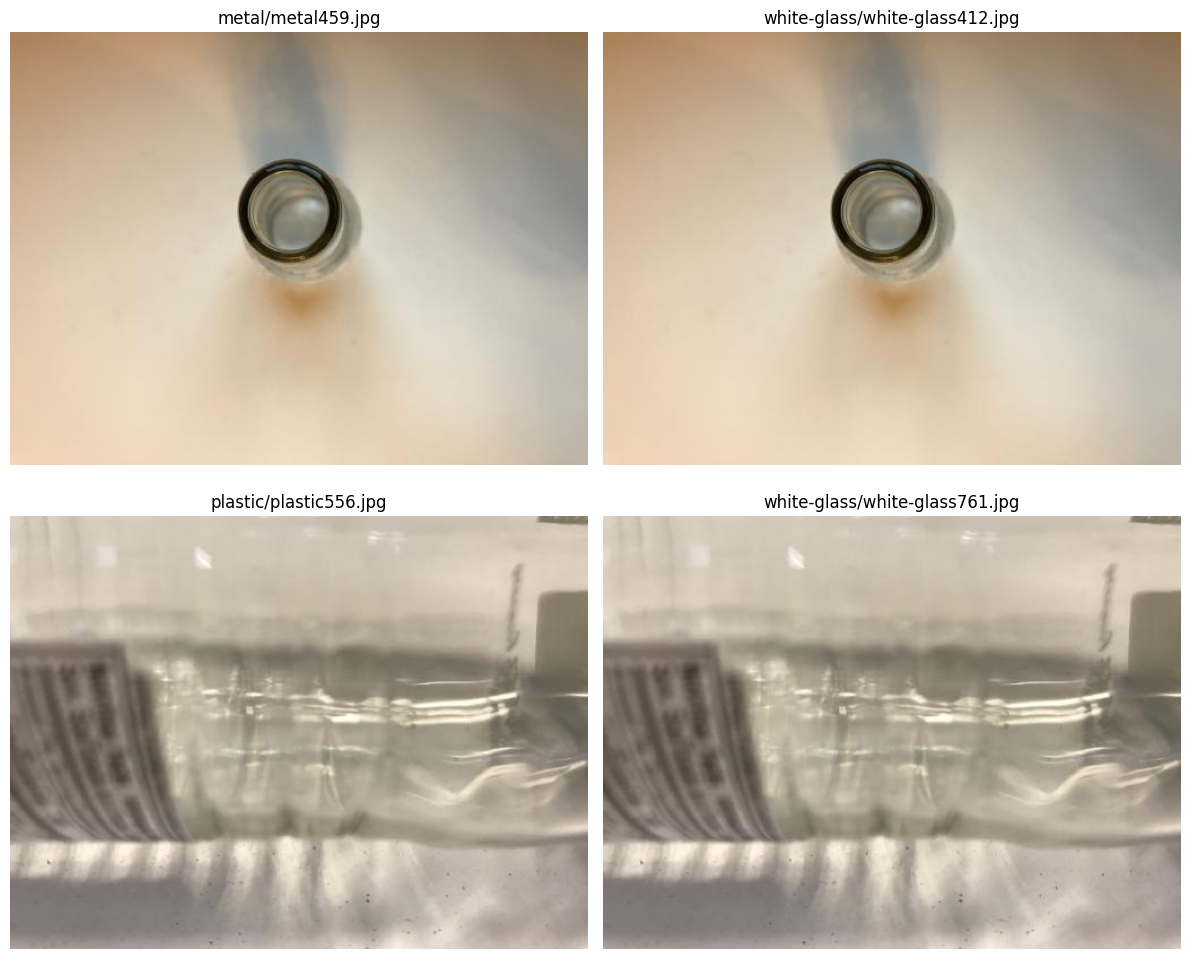

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

duplicate_files = [
    "/content/data/garbage_classification_enhanced/metal/metal459.jpg",
    "/content/data/garbage_classification_enhanced/white-glass/white-glass412.jpg",
    "/content/data/garbage_classification_enhanced/plastic/plastic556.jpg",
    "/content/data/garbage_classification_enhanced/white-glass/white-glass761.jpg"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, image_path in zip(axes, duplicate_files):

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(image_path.split("/")[-2] + "/" + image_path.split("/")[-1])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
import os

files_to_remove = [
    "/content/data/garbage_classification_enhanced/metal/metal459.jpg",
    "/content/data/garbage_classification_enhanced/plastic/plastic556.jpg"
]

for file_path in files_to_remove:
    if os.path.exists(file_path):
        os.remove(file_path)
        print("Removed:", file_path)
    else:
        print("Not found:", file_path)

Removed: /content/data/garbage_classification_enhanced/metal/metal459.jpg
Removed: /content/data/garbage_classification_enhanced/plastic/plastic556.jpg


In [14]:
print("Remaining selected images:", 8578 - 2)

Remaining selected images: 8576


In [15]:
import os
import pandas as pd

dataset_path = "/content/data/garbage_classification_enhanced"

selected_classes = [
    "battery",
    "biological",
    "brown-glass",
    "cardboard",
    "green-glass",
    "metal",
    "paper",
    "plastic",
    "trash",
    "white-glass"
]

final_counts = []

for class_name in selected_classes:
    class_path = os.path.join(dataset_path, class_name)

    count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ])

    final_counts.append({
        "Class": class_name,
        "Images": count
    })

final_counts_df = pd.DataFrame(final_counts)

display(final_counts_df)

print("\nTotal images:", final_counts_df["Images"].sum())
print("Number of classes:", len(final_counts_df))
print("Minimum class size:", final_counts_df["Images"].min())
print("Maximum class size:", final_counts_df["Images"].max())

,Class,Images
0,battery,979
1,biological,1035
2,brown-glass,619
3,cardboard,936
4,green-glass,641
5,metal,836
6,paper,1108
7,plastic,900
8,trash,726
9,white-glass,796



Total images: 8576
Number of classes: 10
Minimum class size: 619
Maximum class size: 1108


In [16]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

dataset_path = "/content/data/garbage_classification_enhanced"

selected_classes = [
    "battery",
    "biological",
    "brown-glass",
    "cardboard",
    "green-glass",
    "metal",
    "paper",
    "plastic",
    "trash",
    "white-glass"
]

# Create dataframe of image paths and labels
data = []

for class_name in selected_classes:

    class_path = os.path.join(dataset_path, class_name)

    for filename in os.listdir(class_path):

        if filename.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):

            image_path = os.path.join(class_path, filename)

            data.append({
                "filepath": image_path,
                "label": class_name
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

Total images: 8576

Class distribution:
label
paper          1108
biological     1035
battery         979
cardboard       936
plastic         900
metal           836
white-glass     796
trash           726
green-glass     641
brown-glass     619
Name: count, dtype: int64


In [17]:
# First split: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# Second split: divide the temporary 30% equally
# → 15% validation
# → 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

Train images: 6003
Validation images: 1286
Test images: 1287

Total: 8576


In [19]:
print("TRAINING DISTRIBUTION")
print(train_df["label"].value_counts().sort_index())

print("\nVALIDATION DISTRIBUTION")
print(val_df["label"].value_counts().sort_index())

print("\nTEST DISTRIBUTION")
print(test_df["label"].value_counts().sort_index())

TRAINING DISTRIBUTION
label
battery        685
biological     725
brown-glass    433
cardboard      655
green-glass    449
metal          585
paper          776
plastic        630
trash          508
white-glass    557
Name: count, dtype: int64

VALIDATION DISTRIBUTION
label
battery        147
biological     155
brown-glass     93
cardboard      140
green-glass     96
metal          125
paper          166
plastic        135
trash          109
white-glass    120
Name: count, dtype: int64

TEST DISTRIBUTION
label
battery        147
biological     155
brown-glass     93
cardboard      141
green-glass     96
metal          126
paper          166
plastic        135
trash          109
white-glass    119
Name: count, dtype: int64


In [20]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

class_names = sorted(selected_classes)

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

print("Class mapping:")

for class_name, index in class_to_index.items():
    print(index, "→", class_name)

Class mapping:
0 → battery
1 → biological
2 → brown-glass
3 → cardboard
4 → green-glass
5 → metal
6 → paper
7 → plastic
8 → trash
9 → white-glass


In [22]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label


def create_dataset(dataframe, shuffle=False):
    filepaths = dataframe["filepath"].values

    labels = dataframe["label"].map(class_to_index).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

print("Datasets created successfully!")

Datasets created successfully!


In [23]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print(
    "Pixel range:",
    images.numpy().min(),
    "to",
    images.numpy().max()
)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
Pixel range: 0.0 to 255.0


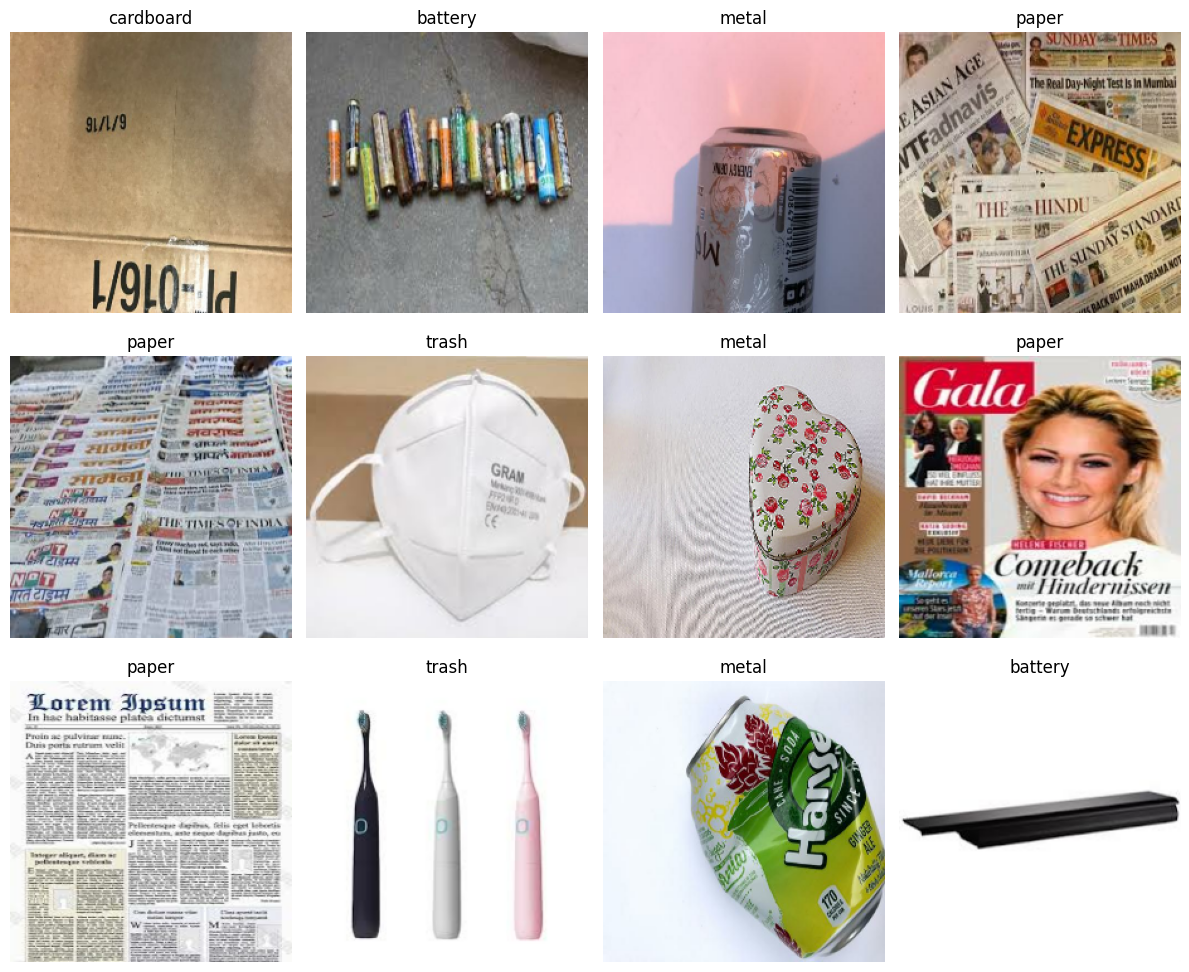

In [24]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 10))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(images[i].numpy().astype("uint8"))

    label_index = labels[i].numpy()
    plt.title(class_names[label_index])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
])

print("Data augmentation pipeline created!")

Data augmentation pipeline created!


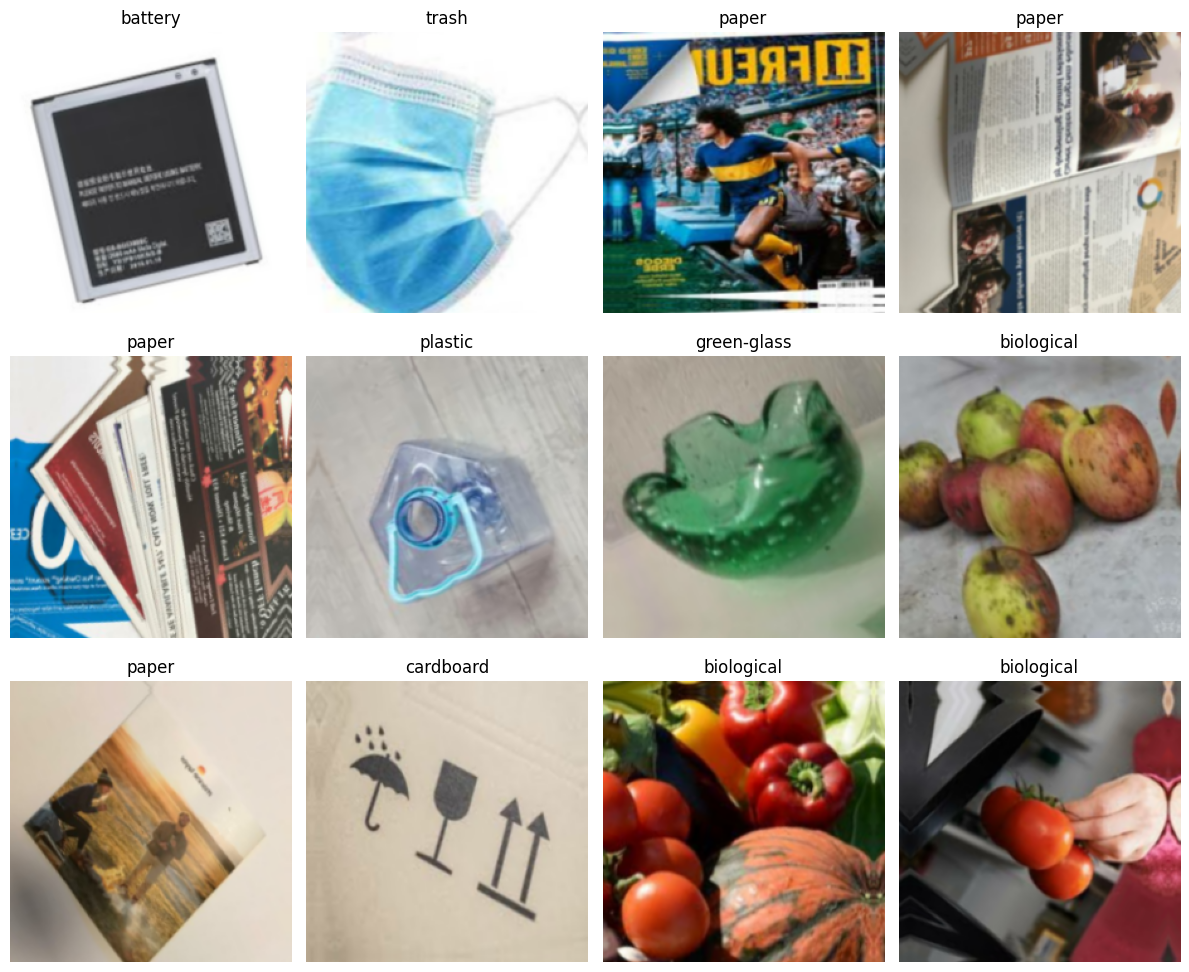

In [26]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 10))

for i in range(12):
    augmented_image = data_augmentation(
        tf.expand_dims(images[i], axis=0),
        training=True
    )[0]

    plt.subplot(3, 4, i + 1)
    plt.imshow(
        tf.cast(
            tf.clip_by_value(augmented_image, 0, 255),
            tf.uint8
        )
    )
    plt.title(class_names[labels[i].numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
baseline_model = tf.keras.Sequential([

    # Input
    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixels from 0-255 to 0-1
    tf.keras.layers.Rescaling(1./255),

    # Convolution block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Convolution block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Convolution block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Reduce spatial dimensions
    tf.keras.layers.GlobalAveragePooling2D(),

    # Fully connected layers
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    # 10 output classes
    tf.keras.layers.Dense(10, activation="softmax")
])

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,050 (433.79 KB)

 Trainable params: 111,050 (433.79 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Baseline CNN compiled successfully!")

Baseline CNN compiled successfully!


In [29]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/content/baseline_cnn_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

print("Training callbacks created!")

Training callbacks created!


In [30]:
EPOCHS = 25

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.2540 - loss: 2.0188 - val_accuracy: 0.3686 - val_loss: 1.7014 - learning_rate: 0.0010
Epoch 2/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.3831 - loss: 1.6882 - val_accuracy: 0.4736 - val_loss: 1.5253 - learning_rate: 0.0010
Epoch 3/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.4433 - loss: 1.5561 - val_accuracy: 0.4930 - val_loss: 1.5637 - learning_rate: 0.0010
Epoch 4/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - accuracy: 0.4673 - loss: 1.5004 - val_accuracy: 0.5163 - val_loss: 1.3963 - learning_rate: 0.0010
Epoch 5/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.5067 - loss: 1.4291 - val_accuracy: 0.5482 - val_loss: 1.3176 - learning_rate: 0.0010
Epoch 6/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.5204 - loss: 1.3831 - val_accuracy: 0.5459 - val_loss: 1.2772 - learning_rate: 0.0010
Epoch 7/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.5282 - l

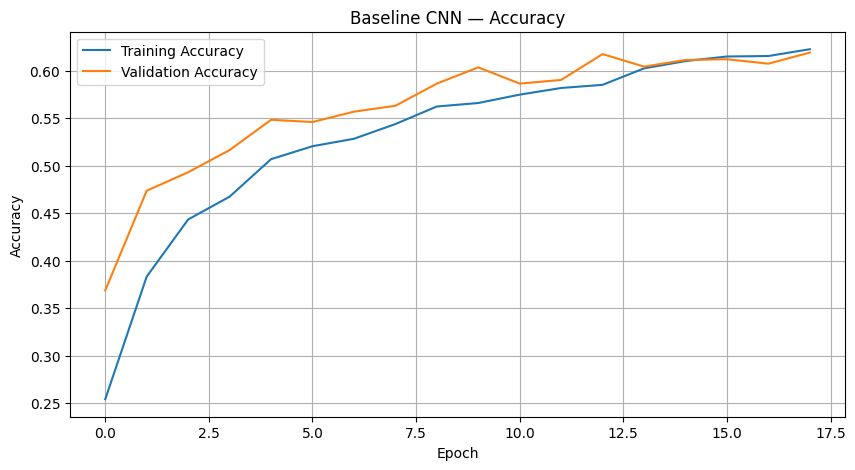

In [31]:
import matplotlib.pyplot as plt

history = history_baseline.history

plt.figure(figsize=(10, 5))

plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")

plt.title("Baseline CNN — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

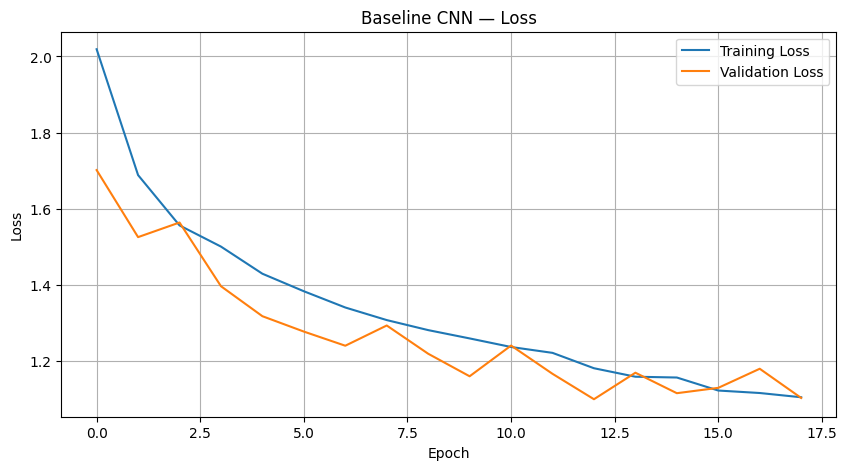

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.title("Baseline CNN — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
test_loss, test_accuracy = baseline_model.evaluate(test_ds, verbose=1)

print("\nBaseline CNN Test Results")
print("-------------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.6185 - loss: 1.1087

Baseline CNN Test Results
-------------------------
Test Loss: 1.1087
Test Accuracy: 0.6185
Test Accuracy: 61.85%


In [34]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Generate predictions
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = baseline_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated!")
print("True labels:", len(y_true))
print("Predicted labels:", len(y_pred))

Predictions generated!
True labels: 1287
Predicted labels: 1287


In [35]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

     battery     0.6122    0.8163    0.6997       147
  biological     0.6242    0.6645    0.6438       155
 brown-glass     0.6636    0.7634    0.7100        93
   cardboard     0.7734    0.7021    0.7361       141
 green-glass     0.7636    0.8750    0.8155        96
       metal     0.5098    0.2063    0.2938       126
       paper     0.5695    0.7651    0.6530       166
     plastic     0.5310    0.4444    0.4839       135
       trash     0.6098    0.6881    0.6466       109
 white-glass     0.4366    0.2605    0.3263       119

    accuracy                         0.6185      1287
   macro avg     0.6094    0.6186    0.6009      1287
weighted avg     0.6058    0.6185    0.5989      1287



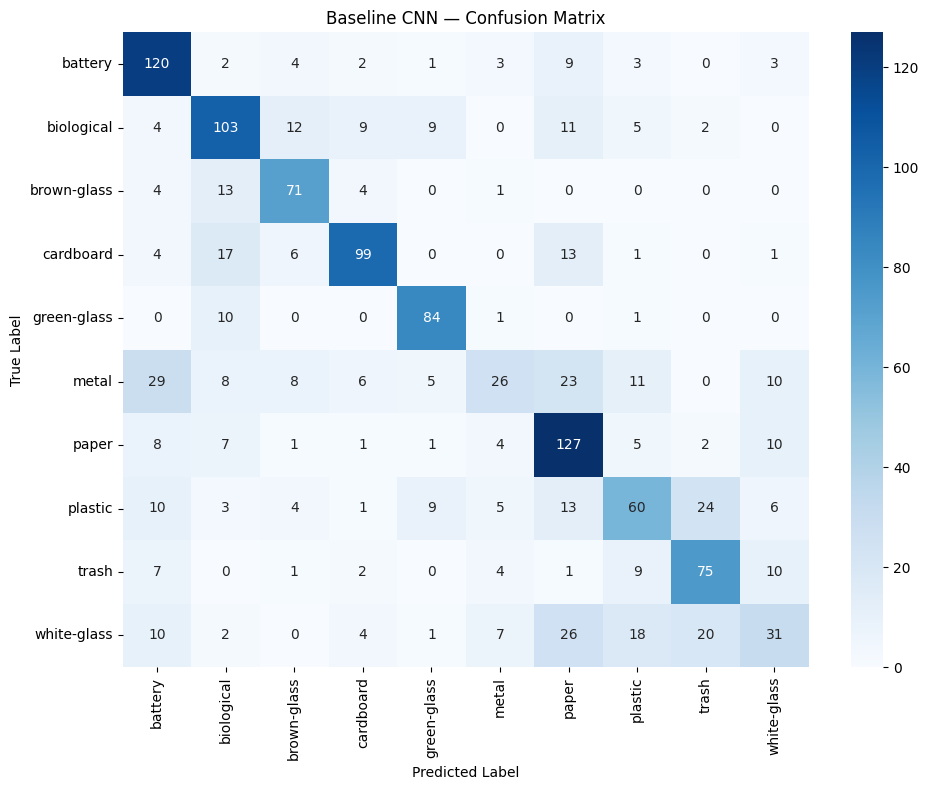

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Baseline CNN — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [37]:
baseline_results = {
    "model": "Custom CNN",
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
    "macro_precision": 0.6407,
    "macro_recall": 0.6339,
    "macro_f1": 0.6238,
    "weighted_f1": 0.6247,
    "parameters": baseline_model.count_params()
}

print(baseline_results)

{'model': 'Custom CNN', 'test_accuracy': 0.618492603302002, 'test_loss': 1.1086864471435547, 'macro_precision': 0.6407, 'macro_recall': 0.6339, 'macro_f1': 0.6238, 'weighted_f1': 0.6247, 'parameters': 111050}


In [38]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 base created!")
print("Trainable:", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 base created!
Trainable: False


In [39]:
inputs = tf.keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# MobileNetV2-specific preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Pretrained feature extractor
x = base_model(x, training=False)

# Convert feature maps to a feature vector
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Regularization
x = tf.keras.layers.Dropout(0.3)(x)

# Our 10-class classifier
outputs = tf.keras.layers.Dense(
    10,
    activation="softmax"
)(x)

mobilenet_model = tf.keras.Model(
    inputs,
    outputs
)

mobilenet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [40]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("MobileNetV2 compiled successfully!")

MobileNetV2 compiled successfully!


In [41]:
mobilenet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/content/mobilenetv2_stage1_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

print("MobileNetV2 callbacks created!")

MobileNetV2 callbacks created!


In [42]:
EPOCHS_MOBILENET = 15

history_mobilenet_stage1 = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_MOBILENET,
    callbacks=mobilenet_callbacks
)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 31s 103ms/step - accuracy: 0.2350 - loss: 2.2270 - val_accuracy: 0.5101 - val_loss: 1.5760 - learning_rate: 1.0000e-04
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.5302 - loss: 1.4504 - val_accuracy: 0.6936 - val_loss: 1.0943 - learning_rate: 1.0000e-04
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.6652 - loss: 1.0936 - val_accuracy: 0.7613 - val_loss: 0.8610 - learning_rate: 1.0000e-04
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.7290 - loss: 0.8936 - val_accuracy: 0.7955 - val_loss: 0.7299 - learning_rate: 1.0000e-04
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.7671 - loss: 0.7694 - val_accuracy: 0.8258 - val_loss: 0.6417 - learning_rate: 1.0000e-04
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.7826 - loss: 0.7042 - val_accuracy: 0.8383 - val_loss: 0.5841 - learning_rate: 1.0000e-04
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/st

In [43]:
mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(
    test_ds,
    verbose=1
)

print("\nMobileNetV2 Stage 1 Test Results")
print("--------------------------------")
print(f"Test Loss: {mobilenet_test_loss:.4f}")
print(f"Test Accuracy: {mobilenet_test_accuracy:.4f}")
print(f"Test Accuracy: {mobilenet_test_accuracy * 100:.2f}%")

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.8640 - loss: 0.4090

MobileNetV2 Stage 1 Test Results
--------------------------------
Test Loss: 0.4090
Test Accuracy: 0.8640
Test Accuracy: 86.40%


In [44]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = mobilenet_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("MobileNetV2 Stage 1 Classification Report")
print("------------------------------------------")
print(report)

MobileNetV2 Stage 1 Classification Report
------------------------------------------
              precision    recall  f1-score   support

     battery     0.8966    0.8844    0.8904       147
  biological     0.9869    0.9742    0.9805       155
 brown-glass     0.9310    0.8710    0.9000        93
   cardboard     0.8819    0.9007    0.8912       141
 green-glass     0.9043    0.8854    0.8947        96
       metal     0.6928    0.8413    0.7599       126
       paper     0.8750    0.8434    0.8589       166
     plastic     0.8246    0.6963    0.7550       135
       trash     0.9626    0.9450    0.9537       109
 white-glass     0.7308    0.7983    0.7631       119

    accuracy                         0.8640      1287
   macro avg     0.8686    0.8640    0.8647      1287
weighted avg     0.8689    0.8640    0.8649      1287



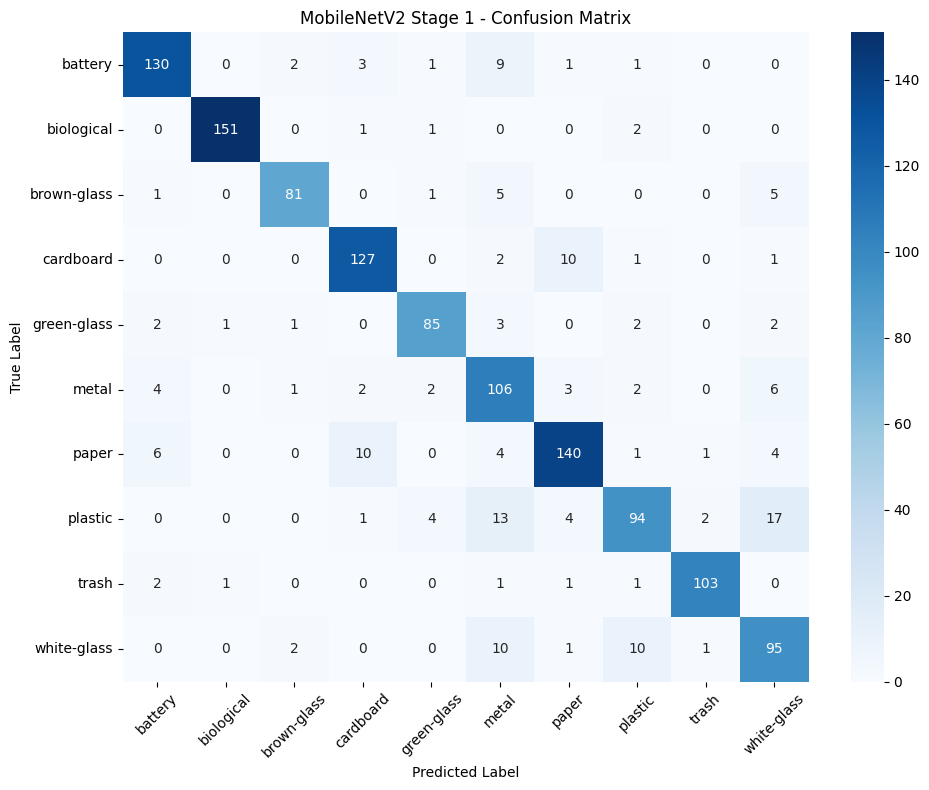

In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 Stage 1 - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
# Fine-tuning: unfreeze the top layers of MobileNetV2

base_model.trainable = True

# Freeze the earlier layers
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total MobileNetV2 layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_at)

trainable_layers = sum(layer.trainable for layer in base_model.layers)
print("Trainable layers:", trainable_layers)

Total MobileNetV2 layers: 154
Fine-tuning from layer: 100
Trainable layers: 36


In [47]:
# Recompile MobileNetV2 for fine-tuning

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")
print("Learning rate: 1e-5")

Model recompiled for fine-tuning.
Learning rate: 1e-5


In [48]:
# Callbacks for fine-tuning

fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/content/mobilenetv2_finetuned_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

# Train the fine-tuned model

fine_tune_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=fine_tune_callbacks
)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8569 - loss: 0.4258
Epoch 1: val_loss improved from None to 0.33194, saving model to /content/mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to /content/mobilenetv2_finetuned_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.8679 - loss: 0.3981 - val_accuracy: 0.8927 - val_loss: 0.3319 - learning_rate: 1.0000e-05
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8842 - loss: 0.3495
Epoch 2: val_loss improved from 0.33194 to 0.32064, saving model to /content/mobilenetv2_finetuned_best.keras

Epoch 2: finished saving model to /content/mobilenetv2_finetuned_best.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 99ms/step - accuracy: 0.8866 - loss: 0.3431 - val_accuracy: 0.8880 - val_loss: 0.3206 - learning_rate: 1.0000e-05
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9014 - loss: 0.2949
Epoch 3: val_loss improved from 0.32064 to 0.26821, saving model to /cont

In [49]:
# Load the best fine-tuned model saved during training

mobilenet_model = tf.keras.models.load_model(
    "/content/mobilenetv2_finetuned_best.keras"
)

print("Best fine-tuned model loaded successfully.")

Best fine-tuned model loaded successfully.


In [50]:
# Evaluate the best fine-tuned MobileNetV2 on the test set

finetuned_test_loss, finetuned_test_accuracy = mobilenet_model.evaluate(
    test_ds,
    verbose=1
)

print("\nMobileNetV2 Stage 2 - Final Test Results")
print("-----------------------------------------")
print(f"Test Loss: {finetuned_test_loss:.4f}")
print(f"Test Accuracy: {finetuned_test_accuracy:.4f}")
print(f"Test Accuracy: {finetuned_test_accuracy * 100:.2f}%")

41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9239 - loss: 0.2335

MobileNetV2 Stage 2 - Final Test Results
-----------------------------------------
Test Loss: 0.2335
Test Accuracy: 0.9239
Test Accuracy: 92.39%


In [51]:
from sklearn.metrics import classification_report
import numpy as np

# Generate predictions using the final fine-tuned model
y_true_stage2 = []
y_pred_stage2 = []

for images, labels in test_ds:
    predictions = mobilenet_model.predict(images, verbose=0)

    y_true_stage2.extend(labels.numpy())
    y_pred_stage2.extend(np.argmax(predictions, axis=1))

y_true_stage2 = np.array(y_true_stage2)
y_pred_stage2 = np.array(y_pred_stage2)

# Classification report
print("MobileNetV2 Stage 2 - Final Classification Report")
print("--------------------------------------------------")

print(
    classification_report(
        y_true_stage2,
        y_pred_stage2,
        target_names=class_names,
        digits=4
    )
)

MobileNetV2 Stage 2 - Final Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

     battery     0.9662    0.9728    0.9695       147
  biological     1.0000    0.9613    0.9803       155
 brown-glass     0.9663    0.9247    0.9451        93
   cardboard     0.9054    0.9504    0.9273       141
 green-glass     0.9474    0.9375    0.9424        96
       metal     0.8271    0.8730    0.8494       126
       paper     0.9128    0.9458    0.9290       166
     plastic     0.8976    0.8444    0.8702       135
       trash     0.9906    0.9633    0.9767       109
 white-glass     0.8417    0.8487    0.8452       119

    accuracy                         0.9239      1287
   macro avg     0.9255    0.9222    0.9235      1287
weighted avg     0.9251    0.9239    0.9241      1287



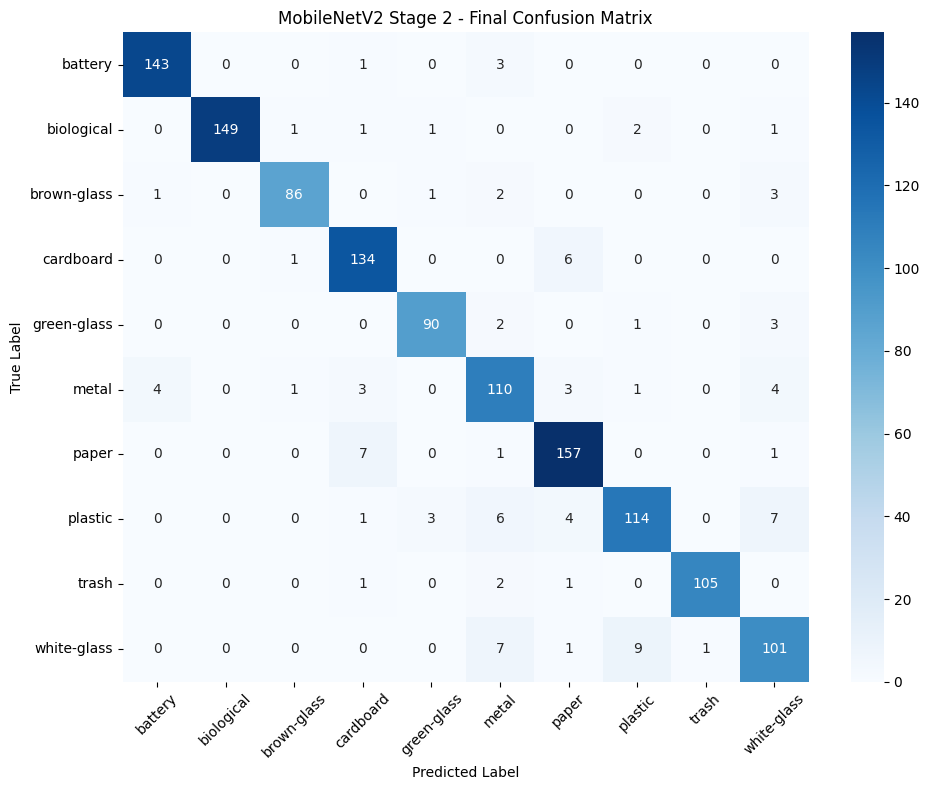

In [52]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_stage2 = confusion_matrix(
    y_true_stage2,
    y_pred_stage2
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_stage2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 Stage 2 - Final Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
import json
import os

# Create an export directory
export_dir = "/content/model_export"
os.makedirs(export_dir, exist_ok=True)

# Save the best fine-tuned model
model_path = os.path.join(
    export_dir,
    "smartwaste_mobilenetv2.keras"
)

mobilenet_model.save(model_path)

# Save class names
class_names_path = os.path.join(
    export_dir,
    "class_names.json"
)

with open(class_names_path, "w") as f:
    json.dump(class_names, f, indent=4)

print("Model exported to:")
print(model_path)

print("\nClass mapping:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

print("\nFiles created:")
print(os.listdir(export_dir))

Model exported to:
/content/model_export/smartwaste_mobilenetv2.keras

Class mapping:
0: battery
1: biological
2: brown-glass
3: cardboard
4: green-glass
5: metal
6: paper
7: plastic
8: trash
9: white-glass

Files created:
['class_names.json', 'smartwaste_mobilenetv2.keras']


In [54]:
from google.colab import files
import shutil

# Create a single ZIP containing the model and class mapping
shutil.make_archive(
    "/content/smartwaste_model_export",
    "zip",
    "/content/model_export"
)

# Download the ZIP
files.download("/content/smartwaste_model_export.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
# ============================================================
# DEEP DIVE 1: Generate predictions from the FINAL model
# ============================================================

import numpy as np
import pandas as pd

# Final fine-tuned model
model = mobilenet_model

# Generate probabilities for the complete test set
y_prob = model.predict(test_ds, verbose=1)

# Predicted class
y_pred = np.argmax(y_prob, axis=1)

# Actual class
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print("Number of predictions :", len(y_pred))
print("Number of true labels :", len(y_true))
print("Number of classes     :", len(class_names))

print("\nClass mapping:")
for i, name in enumerate(class_names):
    print(f"{i} -> {name}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step
Number of predictions : 1287
Number of true labels : 1287
Number of classes     : 10

Class mapping:
0 -> battery
1 -> biological
2 -> brown-glass
3 -> cardboard
4 -> green-glass
5 -> metal
6 -> paper
7 -> plastic
8 -> trash
9 -> white-glass


In [57]:
# ============================================================
# DEEP DIVE 2: Analyze incorrect predictions
# ============================================================

# Confidence of the predicted class
confidence = np.max(y_prob, axis=1)

# Convert numeric labels to class names
true_names = [class_names[i] for i in y_true]
pred_names = [class_names[i] for i in y_pred]

# Create analysis dataframe
error_df = pd.DataFrame({
    "true_class": true_names,
    "predicted_class": pred_names,
    "confidence": confidence
})

# Only incorrect predictions
errors = error_df[error_df["true_class"] != error_df["predicted_class"]].copy()

print("Total test images :", len(error_df))
print("Incorrect images  :", len(errors))
print("Correct images    :", len(error_df) - len(errors))
print("Accuracy          :", (len(error_df) - len(errors)) / len(error_df))

print("\nMost common errors:")
print(
    errors.groupby(["true_class", "predicted_class"])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

Total test images : 1287
Incorrect images  : 98
Correct images    : 1189
Accuracy          : 0.9238539238539238

Most common errors:
true_class   predicted_class
white-glass  plastic            9
plastic      white-glass        7
paper        cardboard          7
white-glass  metal              7
cardboard    paper              6
plastic      metal              6
metal        white-glass        4
plastic      paper              4
metal        battery            4
battery      metal              3
plastic      green-glass        3
green-glass  white-glass        3
brown-glass  white-glass        3
metal        cardboard          3
             paper              3
biological   plastic            2
brown-glass  metal              2
trash        metal              2
green-glass  metal              2
biological   brown-glass        1
dtype: int64


In [58]:
# ============================================================
# DEEP DIVE 3: Confidence of incorrect predictions
# ============================================================

# Sort incorrect predictions by confidence
errors_by_confidence = errors.sort_values(
    "confidence",
    ascending=False
)

print("Top 20 WRONG predictions by confidence:\n")
display(errors_by_confidence.head(20))

print("\n\nConfidence statistics for wrong predictions:")
print(errors["confidence"].describe())

Top 20 WRONG predictions by confidence:



,true_class,predicted_class,confidence
899,white-glass,plastic,0.988026
371,plastic,white-glass,0.986765
1265,cardboard,paper,0.986702
719,plastic,green-glass,0.963000
88,trash,metal,0.959483
1004,plastic,white-glass,0.958140
385,plastic,paper,0.957440
514,plastic,metal,0.955335
465,battery,metal,0.950752
507,white-glass,plastic,0.941824




Confidence statistics for wrong predictions:
count    98.000000
mean      0.749826
std       0.174620
min       0.333014
25%       0.661633
50%       0.784391
75%       0.892781
max       0.988026
Name: confidence, dtype: float64


    index                                           filepath   true_class  \
69    899  /content/data/garbage_classification_enhanced/...  white-glass   
27    371  /content/data/garbage_classification_enhanced/...      plastic   
95   1265  /content/data/garbage_classification_enhanced/...    cardboard   
59    719  /content/data/garbage_classification_enhanced/...      plastic   
5      88  /content/data/garbage_classification_enhanced/...        trash   
78   1004  /content/data/garbage_classification_enhanced/...      plastic   
29    385  /content/data/garbage_classification_enhanced/...      plastic   
38    514  /content/data/garbage_classification_enhanced/...      plastic   
34    465  /content/data/garbage_classification_enhanced/...      battery   
35    507  /content/data/garbage_classification_enhanced/...  white-glass   
22    279  /content/data/garbage_classification_enhanced/...        paper   
96   1273  /content/data/garbage_classification_enhanced/...      plastic   

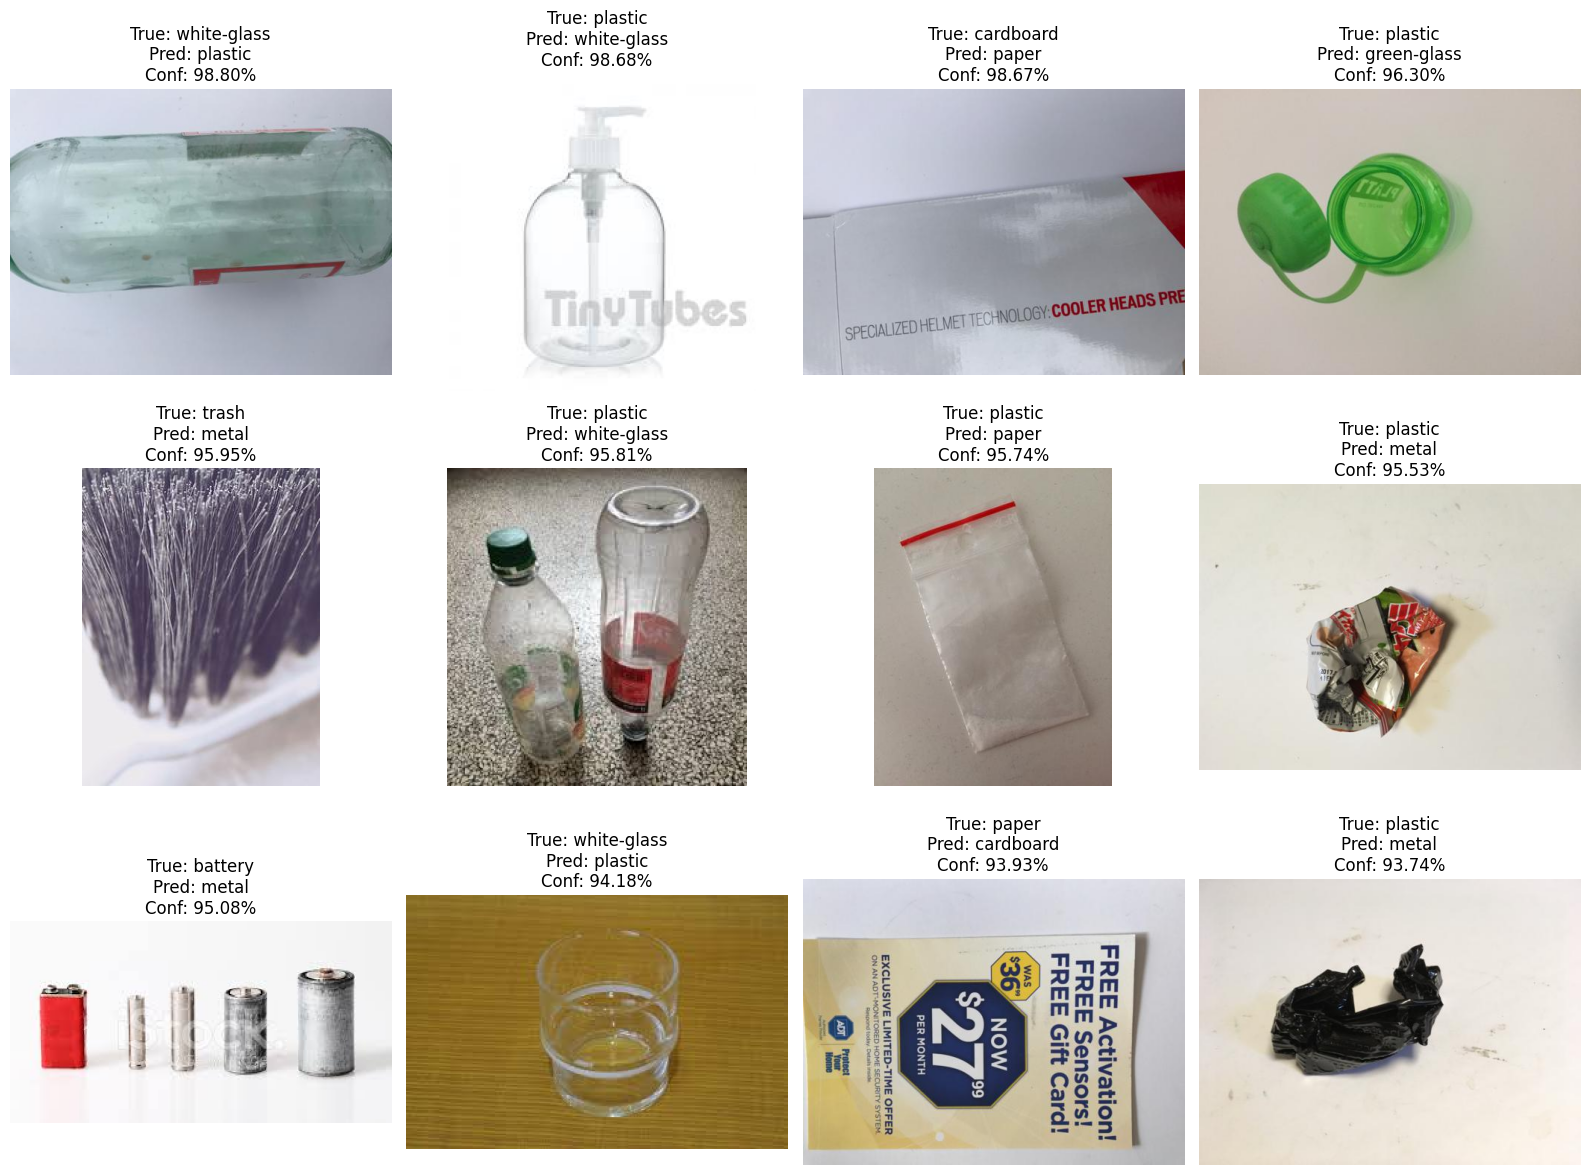

In [59]:
# ============================================================
# DEEP DIVE 4: Visualize highly confident wrong predictions
# ============================================================

import matplotlib.pyplot as plt

# Get test file paths in the same order as test_ds predictions
test_paths = test_df["filepath"].tolist()

# Add filepath to error dataframe
error_indices = np.where(y_true != y_pred)[0]

error_details = pd.DataFrame({
    "index": error_indices,
    "filepath": [test_paths[i] for i in error_indices],
    "true_class": [class_names[y_true[i]] for i in error_indices],
    "predicted_class": [class_names[y_pred[i]] for i in error_indices],
    "confidence": [confidence[i] for i in error_indices]
})

# Highest-confidence mistakes
top_errors = error_details.sort_values(
    "confidence",
    ascending=False
).head(12)

print(top_errors[[
    "index",
    "filepath",
    "true_class",
    "predicted_class",
    "confidence"
]])

# Display images
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, (_, row) in zip(axes, top_errors.iterrows()):
    img = Image.open(row["filepath"]).convert("RGB")

    ax.imshow(img)
    ax.set_title(
        f"True: {row['true_class']}\n"
        f"Pred: {row['predicted_class']}\n"
        f"Conf: {row['confidence']:.2%}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


In [60]:
# ============================================================
# DEEP DIVE 5: Inspect exact filenames of top errors
# ============================================================

print("Top 20 high-confidence errors with full paths:\n")

display(
    top_errors[[
        "index",
        "filepath",
        "true_class",
        "predicted_class",
        "confidence"
    ]].to_string(index=False)
)

Top 20 high-confidence errors with full paths:



' index                                                                     filepath  true_class predicted_class  confidence\n   899 /content/data/garbage_classification_enhanced/white-glass/white-glass165.jpg white-glass         plastic    0.988026\n   371         /content/data/garbage_classification_enhanced/plastic/plastic841.jpg     plastic     white-glass    0.986765\n  1265     /content/data/garbage_classification_enhanced/cardboard/cardboard176.jpg   cardboard           paper    0.986702\n   719         /content/data/garbage_classification_enhanced/plastic/plastic257.jpg     plastic     green-glass    0.963000\n    88             /content/data/garbage_classification_enhanced/trash/trash724.jpg       trash           metal    0.959483\n  1004         /content/data/garbage_classification_enhanced/plastic/plastic669.jpg     plastic     white-glass    0.958140\n   385         /content/data/garbage_classification_enhanced/plastic/plastic893.jpg     plastic           paper    0.957440\

In [61]:
# ============================================================
# DEEP DIVE 6: Find paper1.jpg and identify its dataset split
# ============================================================

import os

matches = []

for root, dirs, files in os.walk("/content/data"):
    for file in files:
        if file.lower() == "paper1.jpg":
            matches.append(os.path.join(root, file))

print("Found paper1.jpg:")
for path in matches:
    print(path)

print("\nSplit information:")

for path in matches:
    if path in train_df["filepath"].values:
        print("TRAIN:", path)
    elif path in val_df["filepath"].values:
        print("VALIDATION:", path)
    elif path in test_df["filepath"].values:
        print("TEST:", path)
    else:
        print("NOT IN ANY SPLIT:", path)

Found paper1.jpg:
/content/data/garbage_classification_corrected/paper/paper1.jpg
/content/data/garbage_classification_enhanced/paper/paper1.jpg

Split information:
NOT IN ANY SPLIT: /content/data/garbage_classification_corrected/paper/paper1.jpg
TRAIN: /content/data/garbage_classification_enhanced/paper/paper1.jpg


In [62]:
# ============================================================
# DEEP DIVE 7: Test paper1.jpg using the final Colab model
# ============================================================

paper_path = "/content/data/garbage_classification_enhanced/paper/paper1.jpg"

img = Image.open(paper_path).convert("RGB")
img_resized = img.resize((224, 224))

img_array = np.array(img_resized, dtype=np.float32)
img_array = (img_array / 127.5) - 1.0
img_array = np.expand_dims(img_array, axis=0)

pred = mobilenet_model.predict(img_array, verbose=0)[0]

top_indices = np.argsort(pred)[::-1][:5]

print("Image:", paper_path)
print("\nTop 5 predictions:\n")

for i in top_indices:
    print(f"{class_names[i]:15s} {pred[i]:.6f} ({pred[i]*100:.2f}%)")

Image: /content/data/garbage_classification_enhanced/paper/paper1.jpg

Top 5 predictions:

cardboard       0.411139 (41.11%)
white-glass     0.150630 (15.06%)
metal           0.101103 (10.11%)
brown-glass     0.099001 (9.90%)
green-glass     0.091597 (9.16%)


Image size: (275, 183)
Expected label: paper


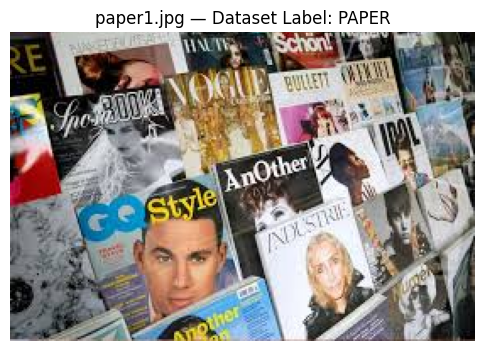

In [63]:
# ============================================================
# DEEP DIVE 8: Inspect paper1.jpg
# ============================================================

paper_path = "/content/data/garbage_classification_enhanced/paper/paper1.jpg"

img = Image.open(paper_path).convert("RGB")

print("Image size:", img.size)
print("Expected label: paper")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("paper1.jpg — Dataset Label: PAPER")
plt.axis("off")
plt.show()

In [64]:
# ============================================================
# DEEP DIVE 9: Paper vs Cardboard confusion
# ============================================================

for cls in ["paper", "cardboard"]:
    cls_errors = errors[errors["true_class"] == cls]

    print(f"\n{cls.upper()}")
    print("Total test images :", (error_df["true_class"] == cls).sum())
    print("Incorrect         :", len(cls_errors))
    print("Error rate        :", len(cls_errors) / (error_df["true_class"] == cls).sum())

    print("\nPredictions for this class:")
    print(cls_errors["predicted_class"].value_counts())


PAPER
Total test images : 166
Incorrect         : 9
Error rate        : 0.05421686746987952

Predictions for this class:
predicted_class
cardboard      7
white-glass    1
metal          1
Name: count, dtype: int64

CARDBOARD
Total test images : 141
Incorrect         : 7
Error rate        : 0.04964539007092199

Predictions for this class:
predicted_class
paper          6
brown-glass    1
Name: count, dtype: int64


In [66]:
mobilenet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,975,648 (22.80 MB)

 Trainable params: 1,852,426 (7.07 MB)

 Non-trainable params: 418,368 (1.60 MB)

 Optimizer params: 3,704,854 (14.13 MB)

In [67]:
# ============================================================
# EXPERIMENT 2: STRONGER DATA AUGMENTATION
# ============================================================

augmentation_v2 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.12),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.08, 0.08),
    tf.keras.layers.RandomContrast(0.10),
], name="augmentation_v2")

augmentation_v2

<Sequential name=augmentation_v2, built=False>

In [68]:
# ============================================================
# EXPERIMENT 2: MobileNetV2 with Stronger Augmentation
# ============================================================

base_model_v2 = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Start with pretrained layers frozen
base_model_v2.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = augmentation_v2(inputs)

# MobileNetV2 preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model_v2(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    10,
    activation="softmax"
)(x)

mobilenet_model_v2 = tf.keras.Model(inputs, outputs)

mobilenet_model_v2.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_v2 (Sequential)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [69]:
# ============================================================
# EXPERIMENT 2 — STAGE 1 TRAINING
# ============================================================

mobilenet_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_v2_stage1 = mobilenet_model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    verbose=1
)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 33s 88ms/step - accuracy: 0.2470 - loss: 2.1948 - val_accuracy: 0.4977 - val_loss: 1.5744
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - accuracy: 0.5247 - loss: 1.4424 - val_accuracy: 0.7030 - val_loss: 1.0916
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - accuracy: 0.6557 - loss: 1.0949 - val_accuracy: 0.7792 - val_loss: 0.8654
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.7133 - loss: 0.9104 - val_accuracy: 0.7994 - val_loss: 0.7385
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.7495 - loss: 0.8024 - val_accuracy: 0.8149 - val_loss: 0.6518
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.7749 - loss: 0.7101 - val_accuracy: 0.8313 - val_loss: 0.5915
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.7913 - loss: 0.6685 - val_accuracy: 0.8398 - val_loss: 0.5536
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.8046 - loss: 0.6134 - 

In [70]:
# ============================================================
# EXPERIMENT 2 — STAGE 2 FINE-TUNING
# ============================================================

base_model_v2.trainable = True

# Freeze the first 100 layers
for layer in base_model_v2.layers[:100]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model_v2.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total MobileNetV2 layers :", len(base_model_v2.layers))
print(
    "Trainable layers :",
    sum(layer.trainable for layer in base_model_v2.layers)
)

mobilenet_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_v2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
]

history_v2_stage2 = mobilenet_model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_v2,
    verbose=1
)

Total MobileNetV2 layers : 154
Trainable layers : 36
Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 37s 104ms/step - accuracy: 0.8511 - loss: 0.4408 - val_accuracy: 0.8849 - val_loss: 0.3486 - learning_rate: 1.0000e-05
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.8719 - loss: 0.3728 - val_accuracy: 0.9005 - val_loss: 0.2995 - learning_rate: 1.0000e-05
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - accuracy: 0.8842 - loss: 0.3372 - val_accuracy: 0.9012 - val_loss: 0.2781 - learning_rate: 1.0000e-05
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - accuracy: 0.8931 - loss: 0.3085 - val_accuracy: 0.8966 - val_loss: 0.3036 - learning_rate: 1.0000e-05
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 95ms/step - accuracy: 0.9009 - loss: 0.2778 - val_accuracy: 0.9067 - val_loss: 0.2609 - learning_rate: 1.0000e-05
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.9107 - loss: 0.2766 - val_accuracy: 0.9106 - val_loss: 0.2524 - learning_rate: 1.0000e-0

In [71]:
# ============================================================
# EXPERIMENT 2 — FINAL TEST EVALUATION
# ============================================================

test_loss_v2, test_acc_v2 = mobilenet_model_v2.evaluate(
    test_ds,
    verbose=1
)

print("\nExperiment 2 Test Results")
print("-------------------------")
print(f"Test Loss     : {test_loss_v2:.4f}")
print(f"Test Accuracy : {test_acc_v2:.4%}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9254 - loss: 0.2177

Experiment 2 Test Results
-------------------------
Test Loss     : 0.2177
Test Accuracy : 92.5408%


In [72]:
# ============================================================
# EXPERIMENT 2 — CLASSIFICATION REPORT
# ============================================================

y_prob_v2 = mobilenet_model_v2.predict(test_ds, verbose=1)
y_pred_v2 = np.argmax(y_prob_v2, axis=1)

y_true_v2 = np.concatenate(
    [y for x, y in test_ds],
    axis=0
)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_v2,
        y_pred_v2,
        target_names=class_names,
        digits=4
    )
)

41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step
              precision    recall  f1-score   support

     battery     0.9595    0.9660    0.9627       147
  biological     1.0000    0.9613    0.9803       155
 brown-glass     0.9659    0.9140    0.9392        93
   cardboard     0.9315    0.9645    0.9477       141
 green-glass     0.9375    0.9375    0.9375        96
       metal     0.8134    0.8651    0.8385       126
       paper     0.9518    0.9518    0.9518       166
     plastic     0.8898    0.8370    0.8626       135
       trash     0.9817    0.9817    0.9817       109
 white-glass     0.8226    0.8571    0.8395       119

    accuracy                         0.9254      1287
   macro avg     0.9254    0.9236    0.9241      1287
weighted avg     0.9267    0.9254    0.9257      1287



In [73]:
# ============================================================
# EXPORT FINAL EXPERIMENT 2 MODEL
# ============================================================

import os
import json

export_dir = "/content/model_export_v2"
os.makedirs(export_dir, exist_ok=True)

# Save model
final_model_path = os.path.join(
    export_dir,
    "smartwaste_mobilenetv2_v2.keras"
)

mobilenet_model_v2.save(final_model_path)

# Save class names
class_names_path = os.path.join(
    export_dir,
    "class_names.json"
)

with open(class_names_path, "w") as f:
    json.dump(class_names, f, indent=2)

print("Model saved to:", final_model_path)
print("Classes saved to:", class_names_path)

Model saved to: /content/model_export_v2/smartwaste_mobilenetv2_v2.keras
Classes saved to: /content/model_export_v2/class_names.json


In [77]:
from google.colab import files
from PIL import Image
import numpy as np
import json

# Upload an image
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Load image
img = Image.open(image_path).convert("RGB")
img = img.resize((224, 224))

# IMPORTANT:
# Do NOT manually normalize to [-1, 1].
# The MobileNetV2 model already contains preprocess_input internally.
img_array = np.array(img, dtype=np.float32)
img_array = np.expand_dims(img_array, axis=0)

# Load Experiment 2 model
model_v2 = tf.keras.models.load_model(
    "/content/model_export_v2/smartwaste_mobilenetv2_v2.keras"
)

# Predict
pred = model_v2.predict(img_array, verbose=0)[0]

predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
confidence = pred[predicted_index]

print("\n==============================")
print("SMARTWASTE AI - TEST")
print("==============================")
print("Image     :", image_path)
print("Prediction:", predicted_class)
print("Confidence:", f"{confidence:.2%}")

print("\nTop 5 predictions:")
top5 = np.argsort(pred)[::-1][:5]

for i in top5:
    print(f"{class_names[i]:15s} {pred[i]:.2%}")

Saving Counter.jpeg to Counter (1).jpeg



SMARTWASTE AI - TEST
Image     : Counter (1).jpeg
Prediction: plastic
Confidence: 99.67%

Top 5 predictions:
plastic         99.67%
white-glass     0.31%
metal           0.01%
cardboard       0.01%
paper           0.00%


In [78]:
import shutil

shutil.make_archive(
    "/content/smartwaste_model_export_v2",
    "zip",
    "/content/model_export_v2"
)

from google.colab import files
files.download("/content/smartwaste_model_export_v2.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>